# Network Metrics Extraction

This notebook loads pre-generated migration network graphs and computes comprehensive network metrics for each granularity level and time period, then exports them to CSV for further analysis.

## Output Files

1. **network_metrics_global.csv**: Global network-level metrics (114 rows)
   - One row per granularity/time period combination
   - Network topology, clustering, path metrics, efficiency, centrality averages, hub counts

2. **network_metrics_nodes.csv**: Node-level metrics (~115,000+ rows)
   - One row per node per granularity/time period combination
   - Degree, centrality measures, clustering, community assignment, hub classification
   
## Granularities

- County (县): ~2,697 nodes
- Prefecture (市): ~331 nodes  
- Province (省): ~31 nodes

## Time Periods

- 1980-2016: Individual years (37 periods)
- "all": Combined network across all years
- Total: 38 time periods per granularity = 114 configurations

In [7]:
import pickle
import networkx as nx
import pandas as pd
import numpy as np
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Import community detection library
try:
    import community as community_louvain
except ImportError:
    import community.community_louvain as community_louvain

In [8]:
# ============================================================================
# SETUP: Define variables needed for Section 7
# ============================================================================

# Define granularities list
granularities = ["county", "prefecture", "province"]

# Load pre-generated graphs (needed for Section 7)
print("Loading pre-generated graphs...")
with open('pre_generated_graphs.pkl', 'rb') as f:
    graphs = pickle.load(f)

print(f"✓ Loaded graphs for {len(graphs)} granularities")
print(f"✓ Granularities: {granularities}")
print("\nReady for Section 7!")

Loading pre-generated graphs...
✓ Loaded graphs for 3 granularities
✓ Granularities: ['county', 'prefecture', 'province']

Ready for Section 7!


## 7. Add Additional Metrics to Existing CSV

This section loads the previously generated CSV and adds new metrics recalculated with random seed = 8:
- **gatewayness (B)**: Z-score of outside-module degree (connections to other communities)
- **provincialness (Z)**: Z-score of inside-module degree (connections within community)
- **connectorness (P)**: Participation coefficient (distribution of connections across communities)
- **rich_club_coefficient**: Unnormalized rich club coefficient for each node

All metrics are recalculated using the same method as FinalNetworkMetrics.ipynb with random seed = 8 for reproducibility.

In [9]:
# ============================================================================
# SET RANDOM SEED FOR REPRODUCIBILITY
# ============================================================================

RANDOM_SEED = 8
np.random.seed(RANDOM_SEED)

print(f"Random seed set to: {RANDOM_SEED}")
print("\nThis seed will be used for:")
print("  - Community detection (Louvain algorithm)")
print("  - Betweenness centrality calculation")
print("  - Rich club coefficient normalization (if applicable)")

Random seed set to: 8

This seed will be used for:
  - Community detection (Louvain algorithm)
  - Betweenness centrality calculation
  - Rich club coefficient normalization (if applicable)


In [10]:
# ============================================================================
# LOAD EXISTING NODE-LEVEL CSV
# ============================================================================

print("Loading existing node-level metrics CSV...")
existing_csv = 'network_metrics_nodes.csv'

try:
    df_existing = pd.read_csv(existing_csv)
    print(f"✓ Loaded {len(df_existing):,} rows from {existing_csv}")
    print(f"\nExisting columns ({len(df_existing.columns)}):")
    for i, col in enumerate(df_existing.columns, 1):
        print(f"  {i:2d}. {col}")
except FileNotFoundError:
    print(f"ERROR: {existing_csv} not found. Please run the previous cells to generate it first.")
    raise

Loading existing node-level metrics CSV...
✓ Loaded 71,690 rows from network_metrics_nodes.csv

Existing columns (21):
   1. granularity
   2. years
   3. year
   4. node_id
   5. degree
   6. degree_unweighted
   7. clustering
   8. local_efficiency
   9. betweenness
  10. closeness
  11. eigenvector
  12. pagerank
  13. radiality
  14. community
  15. participation_coefficient
  16. within_module_degree
  17. hub_type
  18. is_gateway
  19. is_provincial
  20. is_connector
  21. in_lcc


In [12]:
# ============================================================================
# DEFINE FUNCTIONS FOR NEW METRICS
# ============================================================================

def detect_communities_with_seed(G, seed=RANDOM_SEED):
    """
    Detect communities using Louvain algorithm with fixed random seed.
    Returns partition dict and modularity score.
    """
    try:
        partition = community_louvain.best_partition(G, weight='weight', random_state=seed)
        modularity = community_louvain.modularity(partition, G, weight='weight')
    except:
        try:
            communities = nx.community.greedy_modularity_communities(G, weight='weight', seed=seed)
            partition = {}
            for i, comm in enumerate(communities):
                for node in comm:
                    partition[node] = i
            modularity = nx.community.modularity(G, communities, weight='weight')
        except:
            partition = {node: 0 for node in G.nodes()}
            modularity = 0.0
    
    return partition, modularity


def compute_hub_measures(G, partition):
    """
    Compute gateway-ness (B), provincial-ness (Z), and connector-ness (P)
    for all nodes in the network.
    
    Based on FinalNetworkMetrics.ipynb implementation.
    """
    measures = {}
    
    # Group nodes by community
    communities = defaultdict(list)
    for node, comm in partition.items():
        communities[comm].append(node)
    
    for node in G.nodes():
        node_comm = partition[node]
        neighbors = list(G.neighbors(node))
        
        if len(neighbors) == 0:
            measures[node] = {'B': 0, 'Z': 0, 'P': 0}
            continue
        
        # Count inside-module and outside-module connections
        k_inside = sum(1 for n in neighbors if partition[n] == node_comm)
        k_outside = sum(1 for n in neighbors if partition[n] != node_comm)
        
        # Compute Z-score for inside-module degree (Provincial-ness)
        community_nodes = communities[node_comm]
        k_inside_values = []
        for n in community_nodes:
            if n in G:
                n_neighbors = list(G.neighbors(n))
                k_inside_n = sum(1 for nn in n_neighbors if partition[nn] == node_comm)
                k_inside_values.append(k_inside_n)
        
        if len(k_inside_values) > 1:
            mean_k_inside = np.mean(k_inside_values)
            std_k_inside = np.std(k_inside_values)
            Z = (k_inside - mean_k_inside) / std_k_inside if std_k_inside > 0 else 0
        else:
            Z = 0
        
        # Compute Z-score for outside-module degree (Gateway-ness)
        k_outside_values = []
        for n in community_nodes:
            if n in G:
                n_neighbors = list(G.neighbors(n))
                k_outside_n = sum(1 for nn in n_neighbors if partition[nn] != node_comm)
                k_outside_values.append(k_outside_n)
        
        if len(k_outside_values) > 1:
            mean_k_outside = np.mean(k_outside_values)
            std_k_outside = np.std(k_outside_values)
            B = (k_outside - mean_k_outside) / std_k_outside if std_k_outside > 0 else 0
        else:
            B = 0
        
        # Compute participation coefficient (Connector-ness)
        k_total = len(neighbors)
        k_per_module = defaultdict(int)
        for n in neighbors:
            k_per_module[partition[n]] += 1
        
        P = 1 - sum((k_s / k_total) ** 2 for k_s in k_per_module.values())
        
        measures[node] = {'B': B, 'Z': Z, 'P': P}
    
    return measures


def compute_rich_club_coefficient(G, normalized=False, seed=RANDOM_SEED):
    """
    Compute rich club coefficient for a graph.
    
    Parameters:
    - G: NetworkX graph
    - normalized: if True, normalize by random graph (expensive!)
    - seed: random seed for normalization
    
    Returns dict of {degree: rich_club_coef}
    """
    try:
        if normalized:
            rc = nx.rich_club_coefficient(G, normalized=True, seed=seed)
        else:
            rc = nx.rich_club_coefficient(G, normalized=False)
        return rc
    except:
        return {}


def compute_node_rich_club_coefficient(G, seed=RANDOM_SEED):
    """
    Compute rich club coefficient for each node based on its degree.
    
    For each node, we use its degree as k and compute the rich club
    coefficient for that k value.
    
    Returns dict: {node: rich_club_coef}
    """
    node_rc = {}
    
    # Compute rich club coefficient for all k values (UNNORMALIZED)
    rc_dict = compute_rich_club_coefficient(G, normalized=False, seed=seed)
    
    # Assign to each node based on its degree
    for node in G.nodes():
        degree = G.degree(node)  # Unweighted degree
        # Use the rich club coefficient for this degree level
        node_rc[node] = rc_dict.get(degree, np.nan)
    
    return node_rc


print("✓ Functions defined:")
print("  - detect_communities_with_seed()")
print("  - compute_hub_measures() [calculates B, Z, P]")
print("  - compute_rich_club_coefficient()")
print("  - compute_node_rich_club_coefficient()")

✓ Functions defined:
  - detect_communities_with_seed()
  - compute_hub_measures() [calculates B, Z, P]
  - compute_rich_club_coefficient()
  - compute_node_rich_club_coefficient()


In [15]:
# ============================================================================
# COMPUTE NEW METRICS FOR ALL GRAPHS
# ============================================================================

print("Computing new metrics for all graphs...")
print("Metrics to add: gatewayness (B), provincialness (Z), connectorness (P), rich_club_coefficient\n")

all_new_metrics = []

for granularity in granularities:
    print(f"{'='*80}")
    print(f"Processing {granularity.upper()} level...")
    print(f"{'='*80}")
    
    year_keys = list(graphs[granularity].keys())
    year_keys_sorted = sorted([k for k in year_keys if k != 'all']) + (['all'] if 'all' in year_keys else [])
    
    for year_key in year_keys_sorted:
        G = graphs[granularity][year_key]
        
        print(f"\n  Year/Period: {year_key}")
        print(f"  Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
        
        # Detect communities (with fixed seed)
        print(f"  Detecting communities with seed {RANDOM_SEED}...")
        partition, modularity = detect_communities_with_seed(G, seed=RANDOM_SEED)
        
        # Compute hub measures (B, Z, P)
        print(f"  Computing hub measures (B, Z, P)...")
        hub_measures = compute_hub_measures(G, partition)
        
        # Compute rich club coefficient for each node
        print(f"  Computing rich club coefficients...")
        rich_club = compute_node_rich_club_coefficient(G, seed=RANDOM_SEED)
        
        # Store new metrics for each node
        for node in G.nodes():
            measures = hub_measures.get(node, {'B': np.nan, 'Z': np.nan, 'P': np.nan})
            
            new_metrics = {
                'granularity': granularity,
                'years': year_key if year_key == 'all' else str(year_key),
                'year': np.nan if year_key == 'all' else float(year_key),
                'node_id': node,
                'gatewayness': measures['B'],
                'provincialness': measures['Z'],
                'connectorness': measures['P'],
                'rich_club_coefficient': rich_club.get(node, np.nan)
            }
            all_new_metrics.append(new_metrics)
        
        print(f"  ✓ Completed: {len(G.nodes())} nodes processed")

print(f"\n{'='*80}")
print(f"COMPUTATION COMPLETE")
print(f"{'='*80}")
print(f"Total new metric records: {len(all_new_metrics):,}")

Computing new metrics for all graphs...
Metrics to add: gatewayness (B), provincialness (Z), connectorness (P), rich_club_coefficient

Processing COUNTY level...

  Year/Period: 1980
  Graph: 240 nodes, 133 edges
  Detecting communities with seed 8...
  Computing hub measures (B, Z, P)...
  Computing rich club coefficients...
  ✓ Completed: 240 nodes processed

  Year/Period: 1981
  Graph: 161 nodes, 85 edges
  Detecting communities with seed 8...
  Computing hub measures (B, Z, P)...
  Computing rich club coefficients...
  ✓ Completed: 161 nodes processed

  Year/Period: 1982
  Graph: 226 nodes, 135 edges
  Detecting communities with seed 8...
  Computing hub measures (B, Z, P)...
  Computing rich club coefficients...
  ✓ Completed: 226 nodes processed

  Year/Period: 1983
  Graph: 323 nodes, 186 edges
  Detecting communities with seed 8...
  Computing hub measures (B, Z, P)...
  Computing rich club coefficients...
  ✓ Completed: 323 nodes processed

  Year/Period: 1984
  Graph: 293 n

In [16]:
# ============================================================================
# MERGE NEW METRICS WITH EXISTING DATA
# ============================================================================

print("Merging new metrics with existing data...\n")

df_new_metrics = pd.DataFrame(all_new_metrics)

# Ensure years column is string in both dataframes for consistent merging
df_existing['years'] = df_existing['years'].astype(str)
df_new_metrics['years'] = df_new_metrics['years'].astype(str)

# Drop the year column from new metrics to avoid conflicts
df_new_metrics = df_new_metrics.drop(columns=['year'])

# Merge on granularity, years, and node_id
merge_keys = ['granularity', 'years', 'node_id']

df_merged = pd.merge(
    df_existing,
    df_new_metrics[['granularity', 'years', 'node_id', 'gatewayness', 'provincialness', 'connectorness', 'rich_club_coefficient']],
    on=merge_keys,
    how='left',
    suffixes=('_old', '_new')
)

# Replace old columns with new recalculated values
# Drop old participation_coefficient and within_module_degree if they exist
columns_to_drop = []
if 'participation_coefficient' in df_merged.columns:
    columns_to_drop.append('participation_coefficient')
if 'within_module_degree' in df_merged.columns:
    columns_to_drop.append('within_module_degree')

if columns_to_drop:
    df_merged = df_merged.drop(columns=columns_to_drop)
    print(f"Dropped old columns: {columns_to_drop}")

print(f"\n✓ Merged dataframe shape: {df_merged.shape}")
print(f"  New columns added: gatewayness, provincialness, connectorness, rich_club_coefficient\n")

# Check for any missing values in new columns
missing_gateway = df_merged['gatewayness'].isna().sum()
missing_provincial = df_merged['provincialness'].isna().sum()
missing_connector = df_merged['connectorness'].isna().sum()
missing_rc = df_merged['rich_club_coefficient'].isna().sum()

print(f"Missing values in new columns:")
print(f"  - gatewayness: {missing_gateway:,} ({100*missing_gateway/len(df_merged):.2f}%)")
print(f"  - provincialness: {missing_provincial:,} ({100*missing_provincial/len(df_merged):.2f}%)")
print(f"  - connectorness: {missing_connector:,} ({100*missing_connector/len(df_merged):.2f}%)")
print(f"  - rich_club_coefficient: {missing_rc:,} ({100*missing_rc/len(df_merged):.2f}%)")

print("\n✓ All metrics recalculated with random seed = 8")

Merging new metrics with existing data...

Dropped old columns: ['participation_coefficient', 'within_module_degree']

✓ Merged dataframe shape: (71690, 23)
  New columns added: gatewayness, provincialness, connectorness, rich_club_coefficient

Missing values in new columns:
  - gatewayness: 12,073 (16.84%)
  - provincialness: 12,073 (16.84%)
  - connectorness: 12,073 (16.84%)
  - rich_club_coefficient: 12,174 (16.98%)

✓ All metrics recalculated with random seed = 8


In [17]:
# ============================================================================
# REORDER COLUMNS FOR BETTER READABILITY
# ============================================================================

print("Reordering columns...\n")

# Define desired column order
column_order = [
    'granularity', 'years', 'year', 'node_id',
    'degree', 'degree_unweighted',
    'clustering', 'local_efficiency',
    'betweenness', 'closeness', 'eigenvector', 'pagerank', 'radiality',
    'community',
    'gatewayness', 'provincialness', 'connectorness',
    'rich_club_coefficient',
    'hub_type', 'is_gateway', 'is_provincial', 'is_connector',
    'in_lcc'
]

# Ensure all columns exist
missing_cols = [col for col in column_order if col not in df_merged.columns]
if missing_cols:
    print(f"WARNING: The following columns are not in the dataframe: {missing_cols}\n")

# Reorder (only include columns that exist)
available_cols = [col for col in column_order if col in df_merged.columns]
df_merged = df_merged[available_cols]

print(f"✓ Columns reordered ({len(df_merged.columns)} total):")
for i, col in enumerate(df_merged.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n" + "="*80)
print("UPDATED DATAFRAME PREVIEW")
print("="*80)
display(df_merged.head(10))

Reordering columns...

✓ Columns reordered (23 total):
   1. granularity
   2. years
   3. year
   4. node_id
   5. degree
   6. degree_unweighted
   7. clustering
   8. local_efficiency
   9. betweenness
  10. closeness
  11. eigenvector
  12. pagerank
  13. radiality
  14. community
  15. gatewayness
  16. provincialness
  17. connectorness
  18. rich_club_coefficient
  19. hub_type
  20. is_gateway
  21. is_provincial
  22. is_connector
  23. in_lcc

UPDATED DATAFRAME PREVIEW


,granularity,years,year,node_id,degree,degree_unweighted,clustering,local_efficiency,betweenness,closeness,...,community,gatewayness,provincialness,connectorness,rich_club_coefficient,hub_type,is_gateway,is_provincial,is_connector,in_lcc
0,county,1980,1980.0,511323,1,1,0.0,0.0,0.000000,0.005579,...,0,0.0,-0.707107,0.0,0.014286,none,0,0,0,0
1,county,1980,1980.0,150981,2,2,0.0,0.0,0.000035,0.008368,...,0,0.0,1.414214,0.0,0.166667,none,0,0,0,0
2,county,1980,1980.0,500231,1,1,0.0,0.0,0.000000,0.004184,...,1,0.0,0.000000,0.0,0.014286,none,0,0,0,0
3,county,1980,1980.0,532501,1,1,0.0,0.0,0.000000,0.004184,...,1,0.0,0.000000,0.0,0.014286,none,0,0,0,0
4,county,1980,1980.0,150924,1,1,0.0,0.0,0.000000,0.004184,...,2,0.0,0.000000,0.0,0.014286,none,0,0,0,0
5,county,1980,1980.0,150104,1,1,0.0,0.0,0.000000,0.004184,...,2,0.0,0.000000,0.0,0.014286,none,0,0,0,0
6,county,1980,1980.0,512021,1,1,0.0,0.0,0.000000,0.004184,...,3,0.0,0.000000,0.0,0.014286,none,0,0,0,0
7,county,1980,1980.0,510107,1,1,0.0,0.0,0.000000,0.004184,...,3,0.0,0.000000,0.0,0.014286,none,0,0,0,0
8,county,1980,1980.0,520524,1,1,0.0,0.0,0.000000,0.005579,...,4,0.0,-0.707107,0.0,0.014286,none,0,0,0,0
9,county,1980,1980.0,520181,2,2,0.0,0.0,0.000035,0.008368,...,4,0.0,1.414214,0.0,0.166667,none,0,0,0,0


In [18]:
# ============================================================================
# SAVE UPDATED CSV
# ============================================================================

print("Saving updated CSV...\n")

output_file = 'network_metrics_nodes_updated.csv'
df_merged.to_csv(output_file, index=False)

print(f"✓ Successfully saved to: {output_file}")
print(f"  Rows: {len(df_merged):,}")
print(f"  Columns: {len(df_merged.columns)}")
print(f"\n✓ Random seed used: {RANDOM_SEED}")
print("\nNote: To use these updated metrics, load this CSV instead of the original one.")

Saving updated CSV...

✓ Successfully saved to: network_metrics_nodes_updated.csv
  Rows: 71,690
  Columns: 23

✓ Random seed used: 8

Note: To use these updated metrics, load this CSV instead of the original one.


In [19]:
# ============================================================================
# SUMMARY STATISTICS FOR UPDATED METRICS
# ============================================================================

print("="*80)
print("SUMMARY STATISTICS BY GRANULARITY")
print("="*80)

for granularity in granularities:
    gran_df = df_merged[df_merged['granularity'] == granularity]
    
    print(f"\n{granularity.upper()} Level:")
    print(f"  Total records: {len(gran_df):,}")
    print(f"\n  Hub Classification Scores (mean ± std):")
    print(f"    Gatewayness:     {gran_df['gatewayness'].mean():.4f} ± {gran_df['gatewayness'].std():.4f}")
    print(f"    Provincialness:  {gran_df['provincialness'].mean():.4f} ± {gran_df['provincialness'].std():.4f}")
    print(f"    Connectorness:   {gran_df['connectorness'].mean():.4f} ± {gran_df['connectorness'].std():.4f}")
    
    print(f"\n  Rich Club Coefficient:")
    print(f"    Mean: {gran_df['rich_club_coefficient'].mean():.4f}")
    print(f"    Std:  {gran_df['rich_club_coefficient'].std():.4f}")
    print(f"    Min:  {gran_df['rich_club_coefficient'].min():.4f}")
    print(f"    Max:  {gran_df['rich_club_coefficient'].max():.4f}")
    
    # Count nodes exceeding hub thresholds
    high_gateway = (gran_df['gatewayness'] >= 1.5).sum()
    high_provincial = (gran_df['provincialness'] >= 1.5).sum()
    high_connector = (gran_df['connectorness'] >= 0.7).sum()
    
    print(f"\n  Nodes Exceeding Hub Thresholds:")
    print(f"    Gateway (≥1.5):      {high_gateway:,} ({100*high_gateway/len(gran_df):.2f}%)")
    print(f"    Provincial (≥1.5):   {high_provincial:,} ({100*high_provincial/len(gran_df):.2f}%)")
    print(f"    Connector (≥0.7):    {high_connector:,} ({100*high_connector/len(gran_df):.2f}%)")

print("\n" + "="*80)
print("COMPLETE")
print("="*80)

SUMMARY STATISTICS BY GRANULARITY

COUNTY Level:
  Total records: 59,617

  Hub Classification Scores (mean ± std):
    Gatewayness:     0.0000 ± 0.9466
    Provincialness:  0.0000 ± 0.9691
    Connectorness:   0.2537 ± 0.2803

  Rich Club Coefficient:
    Mean: 0.0219
    Std:  0.0541
    Min:  0.0000
    Max:  1.0000

  Nodes Exceeding Hub Thresholds:
    Gateway (≥1.5):      3,441 (5.77%)
    Provincial (≥1.5):   4,015 (6.73%)
    Connector (≥0.7):    3,957 (6.64%)

PREFECTURE Level:
  Total records: 10,905

  Hub Classification Scores (mean ± std):
    Gatewayness:     nan ± nan
    Provincialness:  nan ± nan
    Connectorness:   nan ± nan

  Rich Club Coefficient:
    Mean: nan
    Std:  nan
    Min:  nan
    Max:  nan

  Nodes Exceeding Hub Thresholds:
    Gateway (≥1.5):      0 (0.00%)
    Provincial (≥1.5):   0 (0.00%)
    Connector (≥0.7):    0 (0.00%)

PROVINCE Level:
  Total records: 1,168

  Hub Classification Scores (mean ± std):
    Gatewayness:     nan ± nan
    Provinci

## Summary of Updates

### What Changed

1. **Added Random Seed**: Set `RANDOM_SEED = 8` for reproducibility in:
   - Community detection (Louvain algorithm)
   - Hub measures calculation (B, Z, P)
   - Rich club coefficient computation

2. **New Metrics Calculated**:
   - `gatewayness (B)`: Z-score of outside-module degree - measures connections to OTHER communities
   - `provincialness (Z)`: Z-score of inside-module degree - measures connections WITHIN community
   - `connectorness (P)`: Participation coefficient - measures distribution across communities
   - `rich_club_coefficient`: Unnormalized rich club coefficient for each node

3. **Calculation Method**:
   - Based on FinalNetworkMetrics.ipynb implementation
   - Replaces old `participation_coefficient` and `within_module_degree` with freshly calculated values
   - All metrics use the same random seed for consistency

4. **Hub Classification Thresholds**:
   - **Gateway Hub**: B ≥ 1.5 (high outside-module connections)
   - **Provincial Hub**: Z ≥ 1.5 (high inside-module connections)
   - **Connector Hub**: P ≥ 0.7 (evenly distributed connections)

### Output Files

- **network_metrics_nodes_updated.csv**: Updated node-level metrics with recalculated B, Z, P values and rich club coefficient
- Binary hub indicators (`is_gateway`, `is_provincial`, `is_connector`) from original CSV are retained for reference

## 8. Community-Level Analysis and Pearson Correlations

This section shows how to aggregate node-level metrics to the community level and calculate Pearson correlations between different metrics. This is useful for understanding relationships between network properties and other variables at the community scale.

In [22]:
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

print("✓ Imported correlation and visualization libraries")

✓ Imported correlation and visualization libraries


### 8.1 Aggregate Node Metrics by Community

First, we aggregate node-level metrics to community-level statistics (mean, std, min, max, median).

In [23]:
# ============================================================================
# AGGREGATE NODE METRICS BY COMMUNITY
# ============================================================================

def aggregate_by_community(df, granularity, metrics_to_aggregate):
    """
    Aggregate node-level metrics to community level.
    
    Parameters:
    - df: DataFrame with node-level metrics
    - granularity: 'county', 'prefecture', or 'province'
    - metrics_to_aggregate: list of metric column names to aggregate
    
    Returns DataFrame with community-level aggregated metrics
    """
    df_filtered = df[df['granularity'] == granularity].copy()
    
    # Group by year and community
    agg_dict = {}
    for metric in metrics_to_aggregate:
        if metric in df_filtered.columns:
            agg_dict[metric] = ['mean', 'std', 'min', 'max', 'median']
    
    # Add count
    agg_dict['node_id'] = 'count'
    
    df_agg = df_filtered.groupby(['year', 'community']).agg(agg_dict).reset_index()
    
    # Flatten column names
    df_agg.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                      for col in df_agg.columns.values]
    
    # Rename count column
    df_agg = df_agg.rename(columns={'node_id_count': 'n_nodes'})
    
    return df_agg


# Define metrics to aggregate
metrics_to_agg = [
    'degree', 'degree_unweighted', 'betweenness', 'closeness', 
    'eigenvector', 'pagerank', 'clustering', 'local_efficiency',
    'radiality', 'gatewayness', 'provincialness', 'connectorness',
    'rich_club_coefficient'
]

print("Aggregating metrics by community...\n")

# Aggregate for each granularity
community_agg_dict = {}

for granularity in granularities:
    print(f"Processing {granularity} level...")
    df_comm_agg = aggregate_by_community(df_merged, granularity, metrics_to_agg)
    community_agg_dict[granularity] = df_comm_agg
    print(f"  ✓ Created {len(df_comm_agg)} community-year combinations")

print("\n" + "="*80)
print("COMMUNITY AGGREGATION COMPLETE")
print("="*80)

# Display example for county level
print("\nExample: County-level community aggregation (first 5 rows):")
display(community_agg_dict['county'].head())

Aggregating metrics by community...

Processing county level...
  ✓ Created 2993 community-year combinations
Processing prefecture level...
  ✓ Created 486 community-year combinations
Processing province level...
  ✓ Created 149 community-year combinations

COMMUNITY AGGREGATION COMPLETE

Example: County-level community aggregation (first 5 rows):


,year,community,degree_mean,degree_std,degree_min,degree_max,degree_median,degree_unweighted_mean,degree_unweighted_std,degree_unweighted_min,...,connectorness_std,connectorness_min,connectorness_max,connectorness_median,rich_club_coefficient_mean,rich_club_coefficient_std,rich_club_coefficient_min,rich_club_coefficient_max,rich_club_coefficient_median,n_nodes
0,1980.0,0,1.333333,0.57735,1,2,1.0,1.333333,0.57735,1,...,0.0,0.0,0.0,0.0,0.065079,0.087977,0.014286,0.166667,0.014286,3
1,1980.0,1,1.000000,0.00000,1,1,1.0,1.000000,0.00000,1,...,0.0,0.0,0.0,0.0,0.014286,0.000000,0.014286,0.014286,0.014286,2
2,1980.0,2,1.000000,0.00000,1,1,1.0,1.000000,0.00000,1,...,0.0,0.0,0.0,0.0,0.014286,0.000000,0.014286,0.014286,0.014286,2
3,1980.0,3,1.000000,0.00000,1,1,1.0,1.000000,0.00000,1,...,0.0,0.0,0.0,0.0,0.014286,0.000000,0.014286,0.014286,0.014286,2
4,1980.0,4,1.333333,0.57735,1,2,1.0,1.333333,0.57735,1,...,0.0,0.0,0.0,0.0,0.065079,0.087977,0.014286,0.166667,0.014286,3


### 8.2 Within-Community Correlations

Calculate Pearson correlations between metrics within each community (for nodes in the same community).

In [24]:
# ============================================================================
# WITHIN-COMMUNITY CORRELATIONS
# ============================================================================

def correlate_within_communities(df, year, granularity, metric1, metric2, min_nodes=3):
    """
    Calculate Pearson correlation between two metrics within each community
    for a specific year and granularity.
    
    Parameters:
    - df: DataFrame with node-level metrics
    - year: Year to analyze
    - granularity: 'county', 'prefecture', or 'province'
    - metric1, metric2: Column names of metrics to correlate
    - min_nodes: Minimum number of nodes required for correlation (default: 3)
    
    Returns DataFrame with correlation results for each community
    """
    # Filter data
    df_filtered = df[(df['year'] == year) & (df['granularity'] == granularity)].copy()
    
    results = []
    
    for community_id in df_filtered['community'].unique():
        df_comm = df_filtered[df_filtered['community'] == community_id]
        
        # Need at least min_nodes for meaningful correlation
        if len(df_comm) < min_nodes:
            continue
        
        # Remove NaN values
        df_comm_clean = df_comm[[metric1, metric2]].dropna()
        
        if len(df_comm_clean) < min_nodes:
            continue
        
        # Calculate Pearson correlation
        try:
            corr, pval = pearsonr(df_comm_clean[metric1], df_comm_clean[metric2])
            
            results.append({
                'year': year,
                'granularity': granularity,
                'community': community_id,
                'n_nodes': len(df_comm_clean),
                'correlation': corr,
                'p_value': pval,
                'metric1': metric1,
                'metric2': metric2,
                'significant': pval < 0.05
            })
        except:
            continue
    
    return pd.DataFrame(results)


# Example: Correlate degree and betweenness within communities for 2010
print("Example: Within-community correlations (degree vs betweenness, 2010, county level)\n")

corr_within = correlate_within_communities(
    df_merged,
    year=2010,
    granularity='county',
    metric1='degree',
    metric2='betweenness'
)

print(f"Found {len(corr_within)} communities with sufficient data")
print(f"Significant correlations (p < 0.05): {corr_within['significant'].sum()}")
print(f"\nMean correlation: {corr_within['correlation'].mean():.4f}")
print(f"Median correlation: {corr_within['correlation'].median():.4f}\n")

print("Top 10 communities by correlation strength:")
display(corr_within.nlargest(10, 'correlation')[['community', 'n_nodes', 'correlation', 'p_value', 'significant']])

Example: Within-community correlations (degree vs betweenness, 2010, county level)

Found 15 communities with sufficient data
Significant correlations (p < 0.05): 15

Mean correlation: 0.8715
Median correlation: 0.8781

Top 10 communities by correlation strength:


,community,n_nodes,correlation,p_value,significant
13,13,4,1.000000,4.440892e-16,True
5,5,29,0.946933,7.862603e-15,True
4,8,357,0.941772,4.160206e-170,True
14,10,5,0.940315,1.734609e-02,True
1,9,353,0.929543,3.705037e-154,True
12,18,129,0.901718,4.377326e-48,True
8,11,353,0.897626,6.159386e-127,True
6,6,72,0.878079,4.219047e-24,True
10,15,98,0.870618,2.475679e-31,True
0,1,143,0.850939,2.943452e-41,True


### 8.3 Cross-Community Correlations

Calculate correlations between aggregated community-level metrics across different communities.

In [25]:
# ============================================================================
# CROSS-COMMUNITY CORRELATIONS (AGGREGATED METRICS)
# ============================================================================

def correlate_community_aggregates(df_comm_agg, year, metric1, metric2, stat='mean'):
    """
    Calculate Pearson correlation between two community-level aggregated metrics
    across different communities for a specific year.
    
    Parameters:
    - df_comm_agg: DataFrame with community-level aggregated metrics
    - year: Year to analyze
    - metric1, metric2: Base metric names (without _mean/_std suffix)
    - stat: Statistic to use ('mean', 'std', 'median', etc.)
    
    Returns correlation coefficient and p-value
    """
    df_year = df_comm_agg[df_comm_agg['year'] == year].copy()
    
    col1 = f"{metric1}_{stat}"
    col2 = f"{metric2}_{stat}"
    
    # Remove NaN
    df_clean = df_year[[col1, col2]].dropna()
    
    if len(df_clean) < 3:
        return np.nan, np.nan, 0
    
    try:
        corr, pval = pearsonr(df_clean[col1], df_clean[col2])
        return corr, pval, len(df_clean)
    except:
        return np.nan, np.nan, 0


# Example: Do communities with higher average degree have higher average betweenness?
print("Example: Cross-community correlations (2010, county level)\n")

corr, pval, n = correlate_community_aggregates(
    community_agg_dict['county'],
    year=2010,
    metric1='degree',
    metric2='betweenness',
    stat='mean'
)

print(f"Correlation between community avg degree and avg betweenness:")
print(f"  Correlation: {corr:.4f}")
print(f"  P-value: {pval:.6f}")
print(f"  N communities: {n}")
print(f"  Significant: {'Yes' if pval < 0.05 else 'No'}\n")

# Try multiple metric pairs
print("Multiple metric pairs:")
print("="*80)

metric_pairs = [
    ('degree', 'betweenness'),
    ('degree', 'closeness'),
    ('betweenness', 'gatewayness'),
    ('provincialness', 'clustering'),
    ('connectorness', 'betweenness'),
    ('degree', 'rich_club_coefficient')
]

for m1, m2 in metric_pairs:
    corr, pval, n = correlate_community_aggregates(
        community_agg_dict['county'],
        year=2010,
        metric1=m1,
        metric2=m2,
        stat='mean'
    )
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"{m1:20s} vs {m2:25s}: r={corr:7.4f}, p={pval:.6f} {sig}")

Example: Cross-community correlations (2010, county level)

Correlation between community avg degree and avg betweenness:
  Correlation: 0.9077
  P-value: 0.000000
  N communities: 20
  Significant: Yes

Multiple metric pairs:
degree               vs betweenness              : r= 0.9077, p=0.000000 ***
degree               vs closeness                : r= 0.9044, p=0.000000 ***
betweenness          vs gatewayness              : r= 0.1721, p=0.468207 
provincialness       vs clustering               : r=-0.0745, p=0.754966 
connectorness        vs betweenness              : r= 0.5891, p=0.006277 **
degree               vs rich_club_coefficient    : r= 0.9626, p=0.000000 ***


### 8.4 Correlation Matrix for Community Metrics

Compute a full correlation matrix for all community-level metrics.

Computing correlation matrix for community-level metrics (2010, county level)...

Correlation Matrix (Community average metrics, 2010):


,degree,betweenness,closeness,pagerank,gatewayness,provincialness,connectorness,clustering,rich_club_coefficient
degree,1.000000,0.907660,0.904373,0.340220,0.173974,0.078830,0.702695,0.810456,0.962601
betweenness,0.907660,1.000000,0.840180,0.352893,0.172068,0.098316,0.589075,0.615129,0.934258
closeness,0.904373,0.840180,1.000000,-0.079497,-0.073792,-0.084004,0.903714,0.620156,0.854626
pagerank,0.340220,0.352893,-0.079497,1.000000,0.632041,0.422424,-0.367954,0.441458,0.399722
gatewayness,0.173974,0.172068,-0.073792,0.632041,1.000000,0.773530,-0.255289,0.013486,0.206410
provincialness,0.078830,0.098316,-0.084004,0.422424,0.773530,1.000000,-0.183666,-0.074486,0.092946
connectorness,0.702695,0.589075,0.903714,-0.367954,-0.255289,-0.183666,1.000000,0.411578,0.633683
clustering,0.810456,0.615129,0.620156,0.441458,0.013486,-0.074486,0.411578,1.000000,0.731603
rich_club_coefficient,0.962601,0.934258,0.854626,0.399722,0.206410,0.092946,0.633683,0.731603,1.000000


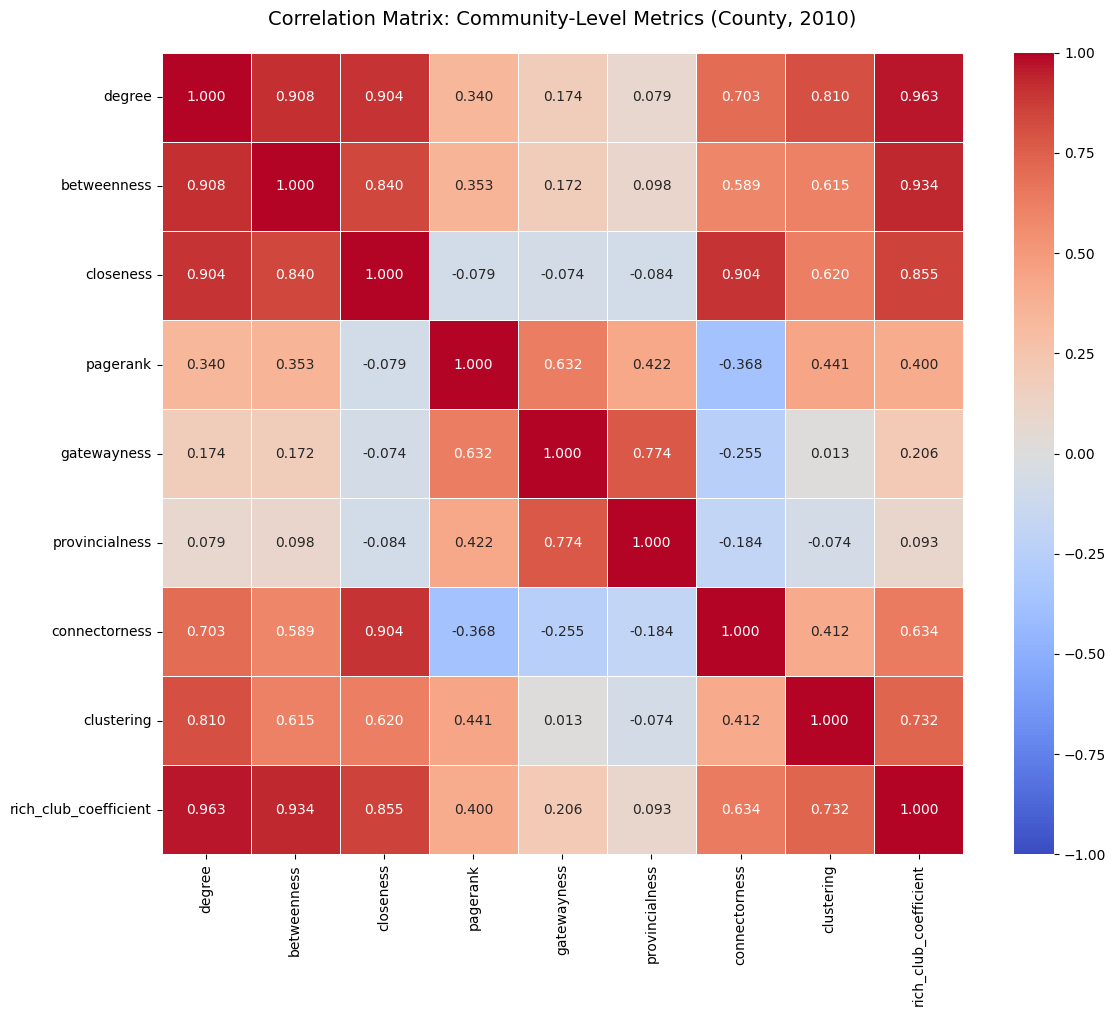


*** Significant correlations (|r| > 0.5):
  degree               vs betweenness              : r=0.9077
  degree               vs closeness                : r=0.9044
  degree               vs connectorness            : r=0.7027
  degree               vs clustering               : r=0.8105
  degree               vs rich_club_coefficient    : r=0.9626
  betweenness          vs closeness                : r=0.8402
  betweenness          vs connectorness            : r=0.5891
  betweenness          vs clustering               : r=0.6151
  betweenness          vs rich_club_coefficient    : r=0.9343
  closeness            vs connectorness            : r=0.9037
  closeness            vs clustering               : r=0.6202
  closeness            vs rich_club_coefficient    : r=0.8546
  pagerank             vs gatewayness              : r=0.6320
  gatewayness          vs provincialness           : r=0.7735
  connectorness        vs rich_club_coefficient    : r=0.6337
  clustering           vs r

In [26]:
# ============================================================================
# CORRELATION MATRIX FOR COMMUNITY METRICS
# ============================================================================

def compute_community_correlation_matrix(df_comm_agg, year, metrics, stat='mean'):
    """
    Compute correlation matrix for community-level metrics for a specific year.
    
    Parameters:
    - df_comm_agg: DataFrame with community-level aggregated metrics
    - year: Year to analyze
    - metrics: List of base metric names
    - stat: Statistic to use ('mean', 'std', 'median', etc.)
    
    Returns correlation matrix
    """
    df_year = df_comm_agg[df_comm_agg['year'] == year].copy()
    
    # Select metric columns
    metric_cols = [f"{m}_{stat}" for m in metrics if f"{m}_{stat}" in df_year.columns]
    
    # Compute correlation matrix
    corr_matrix = df_year[metric_cols].corr(method='pearson')
    
    # Simplify column names for display
    corr_matrix.columns = [col.replace(f'_{stat}', '') for col in corr_matrix.columns]
    corr_matrix.index = [idx.replace(f'_{stat}', '') for idx in corr_matrix.index]
    
    return corr_matrix


# Compute correlation matrix for 2010
metrics_for_corr = [
    'degree', 'betweenness', 'closeness', 'pagerank',
    'gatewayness', 'provincialness', 'connectorness',
    'clustering', 'rich_club_coefficient'
]

print("Computing correlation matrix for community-level metrics (2010, county level)...\n")

corr_matrix_2010 = compute_community_correlation_matrix(
    community_agg_dict['county'],
    year=2010,
    metrics=metrics_for_corr,
    stat='mean'
)

print("Correlation Matrix (Community average metrics, 2010):")
print("="*80)
display(corr_matrix_2010)

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_2010, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Community-Level Metrics (County, 2010)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n*** Significant correlations (|r| > 0.5):")
for i in range(len(corr_matrix_2010)):
    for j in range(i+1, len(corr_matrix_2010)):
        corr_val = corr_matrix_2010.iloc[i, j]
        if abs(corr_val) > 0.5:
            metric1 = corr_matrix_2010.index[i]
            metric2 = corr_matrix_2010.columns[j]
            print(f"  {metric1:20s} vs {metric2:25s}: r={corr_val:.4f}")

### 8.5 Temporal Evolution of Community Metrics

Track how community metrics change over time and compute temporal correlations.

Example: Temporal correlations for top communities (county level)

How do average degree and average betweenness evolve together over time?

Temporal correlations (degree vs betweenness over time):


,community,correlation,p_value,n_years,significant
0,1,0.269247,0.107078,37,False
1,0,0.198595,0.238666,37,False
2,2,0.331992,0.044701,37,True
3,7,0.091875,0.588631,37,False
4,3,0.272131,0.103227,37,False
5,11,0.476171,0.002891,37,True
6,4,0.303100,0.068217,37,False
7,6,0.201635,0.231408,37,False
8,5,0.314013,0.058398,37,False
9,9,0.287797,0.084119,37,False




Computing temporal correlations for all communities...

Temporal correlation statistics (degree vs betweenness, 162 communities):
  Mean correlation: 0.7390
  Median correlation: 0.8028
  Std correlation: 0.2401
  Significant (p < 0.05): 141 (87.0%)


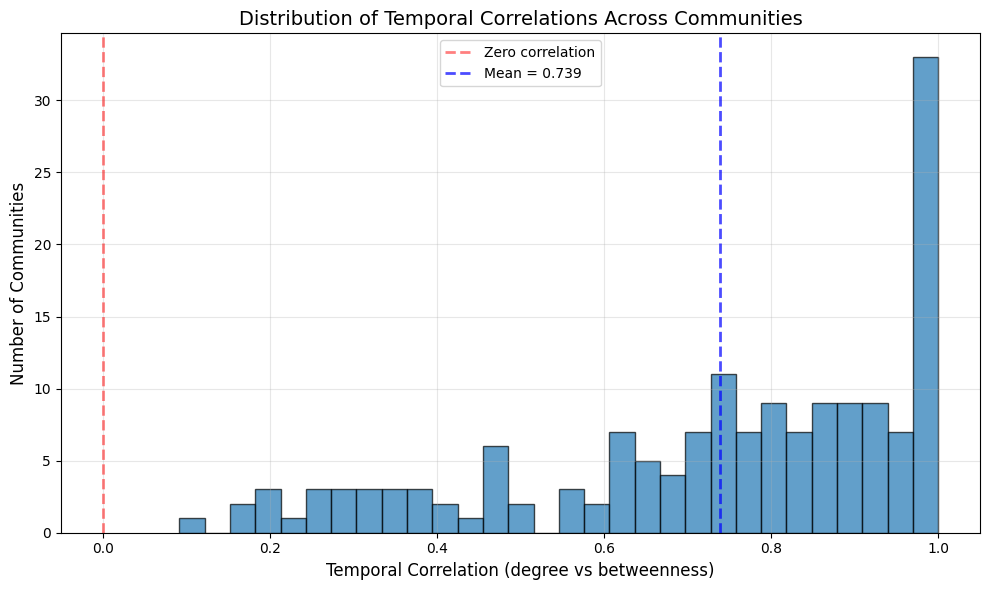

In [27]:
# ============================================================================
# TEMPORAL CORRELATIONS FOR COMMUNITIES
# ============================================================================

def compute_temporal_community_correlation(df_comm_agg, community_id, metric1, metric2, stat='mean'):
    """
    Compute correlation between two metrics over time for a specific community.
    
    Parameters:
    - df_comm_agg: DataFrame with community-level aggregated metrics
    - community_id: Community ID to analyze
    - metric1, metric2: Base metric names
    - stat: Statistic to use ('mean', 'std', 'median', etc.)
    
    Returns correlation coefficient, p-value, and number of time points
    """
    df_comm = df_comm_agg[df_comm_agg['community'] == community_id].copy()
    df_comm = df_comm.sort_values('year')
    
    col1 = f"{metric1}_{stat}"
    col2 = f"{metric2}_{stat}"
    
    # Remove NaN
    df_comm_clean = df_comm[[col1, col2, 'year']].dropna()
    
    if len(df_comm_clean) < 3:
        return np.nan, np.nan, 0
    
    try:
        corr, pval = pearsonr(df_comm_clean[col1], df_comm_clean[col2])
        return corr, pval, len(df_comm_clean)
    except:
        return np.nan, np.nan, 0


# Example: How do degree and betweenness evolve together over time in different communities?
print("Example: Temporal correlations for top communities (county level)\n")
print("How do average degree and average betweenness evolve together over time?\n")

# Get top communities by size (number of nodes)
df_county_agg = community_agg_dict['county']
top_communities = df_county_agg.groupby('community')['n_nodes'].mean().nlargest(10).index

temporal_results = []

for comm_id in top_communities:
    corr, pval, n = compute_temporal_community_correlation(
        df_county_agg,
        community_id=comm_id,
        metric1='degree',
        metric2='betweenness',
        stat='mean'
    )
    
    if not np.isnan(corr):
        temporal_results.append({
            'community': comm_id,
            'correlation': corr,
            'p_value': pval,
            'n_years': n,
            'significant': pval < 0.05
        })

df_temporal = pd.DataFrame(temporal_results)

print("Temporal correlations (degree vs betweenness over time):")
print("="*80)
display(df_temporal)

# Compute temporal correlations for ALL communities
print("\n\nComputing temporal correlations for all communities...")

all_communities = df_county_agg['community'].unique()
temporal_all = []

for comm_id in all_communities:
    corr, pval, n = compute_temporal_community_correlation(
        df_county_agg,
        community_id=comm_id,
        metric1='degree',
        metric2='betweenness',
        stat='mean'
    )
    
    if not np.isnan(corr) and n >= 5:  # At least 5 time points
        temporal_all.append({
            'community': comm_id,
            'correlation': corr,
            'p_value': pval,
            'n_years': n
        })

df_temporal_all = pd.DataFrame(temporal_all)

print(f"\nTemporal correlation statistics (degree vs betweenness, {len(df_temporal_all)} communities):")
print(f"  Mean correlation: {df_temporal_all['correlation'].mean():.4f}")
print(f"  Median correlation: {df_temporal_all['correlation'].median():.4f}")
print(f"  Std correlation: {df_temporal_all['correlation'].std():.4f}")
print(f"  Significant (p < 0.05): {(df_temporal_all['p_value'] < 0.05).sum()} ({100*(df_temporal_all['p_value'] < 0.05).sum()/len(df_temporal_all):.1f}%)")

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(df_temporal_all['correlation'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Temporal Correlation (degree vs betweenness)', fontsize=12)
plt.ylabel('Number of Communities', fontsize=12)
plt.title('Distribution of Temporal Correlations Across Communities', fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Zero correlation')
plt.axvline(x=df_temporal_all['correlation'].mean(), color='blue', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Mean = {df_temporal_all["correlation"].mean():.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.6 Export Community-Level Metrics

Save the aggregated community-level metrics to CSV files for further analysis.

In [ ]:
# ============================================================================
# EXPORT COMMUNITY-LEVEL METRICS
# ============================================================================

print("Exporting community-level aggregated metrics...\n")

# Combine all granularities into one file
all_community_metrics = []

for granularity, df_comm in community_agg_dict.items():
    df_comm_copy = df_comm.copy()
    df_comm_copy['granularity'] = granularity
    all_community_metrics.append(df_comm_copy)

df_all_community = pd.concat(all_community_metrics, ignore_index=True)

# Reorder columns to put granularity first
cols = df_all_community.columns.tolist()
cols = ['granularity'] + [c for c in cols if c != 'granularity']
df_all_community = df_all_community[cols]

# Save to CSV
output_file = 'network_metrics_community_aggregated.csv'
df_all_community.to_csv(output_file, index=False)

print(f"✓ Saved community-level metrics to: {output_file}")
print(f"  Rows: {len(df_all_community):,}")
print(f"  Columns: {len(df_all_community.columns)}")

print("\n" + "="*80)
print("COMMUNITY-LEVEL ANALYSIS COMPLETE")
print("="*80)

print("\n📊 Summary of available data for Pearson correlations:")
print("\n1. Within-community correlations:")
print("   - Correlate metrics for nodes within the same community")
print("   - Use df_merged (node-level data) with community filter")
print("\n2. Cross-community correlations:")
print("   - Correlate aggregated metrics across different communities")
print("   - Use community_agg_dict or df_all_community")
print("\n3. Temporal correlations:")
print("   - Track how metrics evolve together over time within communities")
print("   - Use community_agg_dict with temporal filtering")
print("\n4. Correlation matrices:")
print("   - Full correlation matrix for all metrics at community level")
print("   - Use compute_community_correlation_matrix() function")

print(f"\n✅ You have all the necessary information to calculate Pearson correlations!")

### Summary of Section 8 Outputs

**Community Aggregation Files:**
- `network_metrics_community_aggregated.csv` - Aggregated metrics by community (mean, std, min, max, median)

**Correlation Analysis Files (Network Indicators vs GDP):**
- `correlation_network_gdp_by_community_formatted.csv` - Table with significance markers (**, *)
- `correlation_network_gdp_by_community_values.csv` - Raw correlation coefficients
- `correlation_network_gdp_by_community_pvalues.csv` - P-values for statistical significance
- `correlation_network_gdp_yearly_by_community.csv` - Year-by-year correlations for each community

**Visualizations:**
- `correlation_heatmap_network_gdp_communities.png` - Heatmap of correlations across GLSN and communities

**Key Features:**
- Network indicators: B (gatewayness), Z (provincialness), P (connectorness), K (degree), BC (betweenness), φ (rich club coefficient), and more
- Correlations calculated for GLSN (overall network) and individual communities (C1, C2, ...)
- Significance testing with markers for p < 0.001 (**) and p < 0.01 (*)
- Temporal evolution tracking (year-by-year analysis)

In [ ]:
# ============================================================================
# YEAR-BY-YEAR CORRELATIONS FOR EACH COMMUNITY
# ============================================================================

if econ_data is not None:
    print("Calculating year-by-year correlations...\n")
    
    yearly_community_correlations = []
    
    # Get available years
    available_years = sorted([y for y in merged_network_econ['year'].unique() if not np.isnan(y)])
    
    print(f"Processing {len(available_years)} years and {len(communities)} communities...")
    
    for year in available_years:
        year_data = merged_network_econ[merged_network_econ['year'] == year]
        
        # Overall (GLSN) for this year
        year_results = {'year': int(year), 'community': 'GLSN'}
        
        for metric_key, abbrev in network_indicators.items():
            if metric_key in year_data.columns:
                corr, p_val, n = calculate_correlation_with_gdp(year_data, metric_key)
                year_results[f'{abbrev}_corr'] = corr
                year_results[f'{abbrev}_pval'] = p_val
                year_results[f'{abbrev}_n'] = n
        
        yearly_community_correlations.append(year_results)
        
        # By community for this year
        for community_id in communities:
            comm_year_data = year_data[year_data['community'] == community_id]
            
            # Skip if too few samples
            if len(comm_year_data) < 5:
                continue
            
            comm_year_results = {'year': int(year), 'community': f'C{community_id}'}
            
            for metric_key, abbrev in network_indicators.items():
                if metric_key in comm_year_data.columns:
                    corr, p_val, n = calculate_correlation_with_gdp(comm_year_data, metric_key)
                    comm_year_results[f'{abbrev}_corr'] = corr
                    comm_year_results[f'{abbrev}_pval'] = p_val
                    comm_year_results[f'{abbrev}_n'] = n
            
            yearly_community_correlations.append(comm_year_results)
    
    # Create DataFrame
    df_yearly_comm_corr = pd.DataFrame(yearly_community_correlations)
    
    print(f"✓ Calculated year-by-year correlations: {len(df_yearly_comm_corr)} rows")
    
    # Save to CSV
    df_yearly_comm_corr.to_csv('correlation_network_gdp_yearly_by_community.csv', index=False)
    print("✓ Saved: correlation_network_gdp_yearly_by_community.csv")
    
    print("\nSample (GLSN, first 5 years):")
    glsn_sample = df_yearly_comm_corr[df_yearly_comm_corr['community'] == 'GLSN'].head()
    display(glsn_sample[['year', 'community', 'B_corr', 'Z_corr', 'P_corr', 'K_corr', 'BC_corr']])
    
else:
    print("Skipping - economic data not available")

### 8.8 Year-by-Year Correlations for Each Community

Calculate how correlations between network indicators and GDP evolve over time for each community.

In [ ]:
# ============================================================================
# VISUALIZE CORRELATION HEATMAP
# ============================================================================

if econ_data is not None:
    print("Creating correlation heatmap...\n")
    
    # Prepare data for heatmap (use values table, set Indicator as index)
    heatmap_data = correlation_values_table.set_index('Indicator')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 10))
    
    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1,
                cbar_kws={'label': 'Pearson Correlation Coefficient'},
                linewidths=0.5, linecolor='gray', ax=ax)
    
    plt.title('Pearson Correlation: Network Indicators vs GDP\\n(Across GLSN and Communities)',
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Community / Network', fontsize=12, fontweight='bold')
    plt.ylabel('Network Indicator', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    plt.savefig('correlation_heatmap_network_gdp_communities.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: correlation_heatmap_network_gdp_communities.png")
    
else:
    print("Skipping - economic data not available")

In [ ]:
# ============================================================================
# SAVE CORRELATION TABLES TO CSV
# ============================================================================

if econ_data is not None:
    print("Saving correlation tables to CSV...\n")
    
    # Save formatted table
    correlation_table.to_csv('correlation_network_gdp_by_community_formatted.csv', index=False)
    print("✓ Saved: correlation_network_gdp_by_community_formatted.csv")
    
    # Save values table
    correlation_values_table.to_csv('correlation_network_gdp_by_community_values.csv', index=False)
    print("✓ Saved: correlation_network_gdp_by_community_values.csv")
    
    # Save p-values table
    correlation_pvalues_table.to_csv('correlation_network_gdp_by_community_pvalues.csv', index=False)
    print("✓ Saved: correlation_network_gdp_by_community_pvalues.csv")
    
    print("\n" + "="*80)
    print("CORRELATION ANALYSIS COMPLETE")
    print("="*80)
    
else:
    print("Skipping - economic data not available")

In [ ]:
# ============================================================================
# CREATE CORRELATION TABLE (Similar to Reference Table)
# ============================================================================

if econ_data is not None:
    print("Creating correlation table...\n")
    
    # Create table with network indicators as rows and communities + GLSN as columns
    
    # Prepare data structure
    table_data = []
    
    for metric_key, abbrev in network_indicators.items():
        row = {'Indicator': abbrev, 'Metric': metric_key}
        
        # Add GLSN column
        if abbrev in glsn_correlations:
            row['GLSN'] = glsn_correlations[abbrev]['formatted']
        else:
            row['GLSN'] = '--'
        
        # Add community columns (limit to first 10 for readability)
        for comm_name in sorted(list(community_correlations.keys())[:10]):
            if abbrev in community_correlations[comm_name]:
                row[comm_name] = community_correlations[comm_name][abbrev]['formatted']
            else:
                row[comm_name] = '--'
        
        table_data.append(row)
    
    # Create DataFrame
    correlation_table = pd.DataFrame(table_data)
    
    # Display table
    print("="*120)
    print("TABLE: Pearson Correlation Coefficients between Network Indicators and GDP")
    print("="*120)
    print("\nNote: **p < 0.001, *p < 0.01\n")
    display(correlation_table)
    
    # Also create raw values table and p-values table
    table_values = []
    table_pvalues = []
    
    for metric_key, abbrev in network_indicators.items():
        row_val = {'Indicator': abbrev}
        row_pval = {'Indicator': abbrev}
        
        # GLSN
        if abbrev in glsn_correlations:
            row_val['GLSN'] = glsn_correlations[abbrev]['correlation']
            row_pval['GLSN'] = glsn_correlations[abbrev]['p_value']
        else:
            row_val['GLSN'] = np.nan
            row_pval['GLSN'] = np.nan
        
        # Communities
        for comm_name in sorted(list(community_correlations.keys())[:10]):
            if abbrev in community_correlations[comm_name]:
                row_val[comm_name] = community_correlations[comm_name][abbrev]['correlation']
                row_pval[comm_name] = community_correlations[comm_name][abbrev]['p_value']
            else:
                row_val[comm_name] = np.nan
                row_pval[comm_name] = np.nan
        
        table_values.append(row_val)
        table_pvalues.append(row_pval)
    
    correlation_values_table = pd.DataFrame(table_values)
    correlation_pvalues_table = pd.DataFrame(table_pvalues)
    
    print("\n✓ Created correlation tables (formatted, values, p-values)")
    
else:
    print("Skipping - economic data not available")

In [ ]:
# ============================================================================
# CALCULATE CORRELATIONS: BY COMMUNITY (C1, C2, C3, ...)
# ============================================================================

if econ_data is not None:
    print("Calculating correlations for individual communities...\n")
    
    # Get unique communities
    communities = sorted(merged_network_econ['community'].unique())
    print(f"Found {len(communities)} communities in the merged data")
    
    # Calculate correlations for each community
    community_correlations = {}
    
    for community_id in communities:
        comm_data = merged_network_econ[merged_network_econ['community'] == community_id]
        
        # Skip communities with too few data points
        if len(comm_data) < 10:
            continue
        
        comm_results = {}
        for metric_key, abbrev in network_indicators.items():
            if metric_key in comm_data.columns:
                corr, p_val, n = calculate_correlation_with_gdp(comm_data, metric_key)
                comm_results[abbrev] = {
                    'metric': metric_key,
                    'correlation': corr,
                    'p_value': p_val,
                    'n_samples': n,
                    'formatted': format_correlation_with_sig(corr, p_val)
                }
        
        community_correlations[f'C{community_id}'] = comm_results
    
    print(f"✓ Calculated correlations for {len(community_correlations)} communities (with ≥10 samples)")
    print(f"\nCommunities: {', '.join(list(community_correlations.keys())[:20])}...")
else:
    print("Skipping - economic data not available")

In [ ]:
# ============================================================================
# CALCULATE CORRELATIONS: OVERALL NETWORK (GLSN)
# ============================================================================

if econ_data is not None:
    print("Calculating correlations for overall network (GLSN)...\n")
    
    # GLSN = Global/All network data combined
    glsn_correlations = {}
    
    for metric_key, abbrev in network_indicators.items():
        if metric_key in merged_network_econ.columns:
            corr, p_val, n = calculate_correlation_with_gdp(merged_network_econ, metric_key)
            glsn_correlations[abbrev] = {
                'metric': metric_key,
                'correlation': corr,
                'p_value': p_val,
                'n_samples': n,
                'formatted': format_correlation_with_sig(corr, p_val)
            }
    
    # Display results
    print("GLSN (Overall Network) - Network Indicators vs GDP:")
    print("="*80)
    for abbrev, result in glsn_correlations.items():
        print(f"{abbrev:4s} ({result['metric']:25s}): r={result['formatted']:8s}  "
              f"(p={result['p_value']:.6f}, n={result['n_samples']:,})")
    
    print("\nNote: **p < 0.001, *p < 0.01")
else:
    print("Skipping - economic data not available")

In [ ]:
# ============================================================================
# DEFINE NETWORK INDICATORS AND CORRELATION FUNCTION
# ============================================================================

# Define network indicators to analyze (matching the reference table)
network_indicators = {
    'gatewayness': 'B',          # Gateway-ness
    'provincialness': 'Z',        # Provincial-ness  
    'connectorness': 'P',         # Connector-ness
    'degree': 'K',                # Degree
    'betweenness': 'BC',          # Betweenness Centrality
    'rich_club_coefficient': 'φ', # Rich club coefficient (unnormalized)
    'closeness': 'C',             # Closeness
    'pagerank': 'PR',             # PageRank
    'eigenvector': 'E',           # Eigenvector centrality
    'clustering': 'CC'            # Clustering coefficient
}

def calculate_correlation_with_gdp(data, network_metric, econ_metric='gdp_regional_10k'):
    """
    Calculate Pearson correlation between network metric and economic metric.
    
    Returns: (correlation, p_value, n_samples)
    """
    valid_data = data[[network_metric, econ_metric]].dropna()
    
    if len(valid_data) < 2:
        return np.nan, np.nan, 0
    
    try:
        corr, p_val = pearsonr(valid_data[network_metric], valid_data[econ_metric])
        return corr, p_val, len(valid_data)
    except:
        return np.nan, np.nan, 0

def format_correlation_with_sig(corr, p_val):
    """Format correlation coefficient with significance markers."""
    if np.isnan(corr):
        return '--'
    
    if p_val < 0.001:
        sig_marker = '**'
    elif p_val < 0.01:
        sig_marker = '*'
    else:
        sig_marker = ''
    
    return f"{corr:.2f}{sig_marker}"

print("✓ Network indicators defined:")
for metric_key, abbrev in network_indicators.items():
    print(f"  {abbrev:4s} = {metric_key}")

print("\n✓ Correlation functions defined")

In [ ]:
# ============================================================================
# MERGE NETWORK METRICS WITH ECONOMIC DATA
# ============================================================================

if econ_data is not None:
    print("Merging network metrics with economic data...\n")
    
    # Filter to county level only (most granular)
    df_county = df_merged[df_merged['granularity'] == 'county'].copy()
    
    # Remove 'all' years and ensure year is numeric
    df_county = df_county[df_county['years'] != 'all'].copy()
    df_county['year'] = df_county['year'].astype(float)
    
    # Merge on year and node_id/admin_code
    merged_network_econ = df_county.merge(
        econ_data,
        left_on=['year', 'node_id'],
        right_on=['year', 'admin_code'],
        how='inner'
    )
    
    print(f"✓ Merged data shape: {merged_network_econ.shape}")
    print(f"  Original county network metrics: {len(df_county):,} rows")
    print(f"  Economic data: {len(econ_data):,} rows")
    print(f"  Merged (inner join): {len(merged_network_econ):,} rows")
    
    # Check year coverage
    print(f"\nYear coverage in merged data:")
    print(f"  Years: {sorted(merged_network_econ['year'].unique())}")
    print(f"  Year range: {merged_network_econ['year'].min():.0f} - {merged_network_econ['year'].max():.0f}")
    
    # Check GDP availability
    gdp_available = merged_network_econ['gdp_regional_10k'].notna().sum()
    print(f"\n  GDP data available: {gdp_available:,} / {len(merged_network_econ):,} ({100*gdp_available/len(merged_network_econ):.1f}%)")
    
else:
    print("Skipping merge - economic data not loaded")

In [ ]:
# ============================================================================
# LOAD ECONOMIC DATA
# ============================================================================

print("Loading economic data...")

try:
    econ_data = pd.read_csv('econ_data_en.csv')
    print(f"✓ Loaded economic data: {econ_data.shape}")
    print(f"\nEconomic data columns: {econ_data.columns.tolist()[:10]}...")
    print(f"\nUnique years: {sorted(econ_data['year'].unique())}")
    
    # Check if gdp_regional_10k column exists
    if 'gdp_regional_10k' in econ_data.columns:
        print(f"✓ Found GDP column: gdp_regional_10k")
    else:
        print("WARNING: gdp_regional_10k column not found")
        print(f"Available columns: {econ_data.columns.tolist()}")
        
except FileNotFoundError:
    print("ERROR: econ_data_en.csv not found")
    print("Please ensure the economic data file is in the current directory")
    econ_data = None

### 8.7 Pearson Correlations: Network Indicators vs GDP

Similar to the reference table, we'll compute Pearson correlations between network indicators (B, Z, P, K, BC, φ, etc.) and GDP across different communities and the overall network (GLSN).